In [ ]:
from vit import ViT
import torch
import torchvision
import torchvision.transforms as transforms

# создаем модель
model = ViT()

# загружаем чекпоинт
model.load_state_dict(torch.load("vit_epoch_10.pth"))
model.eval()

print(model)

ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

C:\Users\user\AppData\Local\Temp\ipykernel_7256\3302928597.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vit_epoch_10.pth"))


In [ ]:


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# берем изображение из FashionMNIST
image, label = test_dataset[0]
sample_image = image.unsqueeze(0)

# forward
with torch.no_grad():
    _ = model(sample_image)

# достаем attention
# (batch,heads,tokens,tokens)
attn = model.transformer[0].attn.last_attn
print(attn.shape)


torch.Size([1, 8, 17, 17])


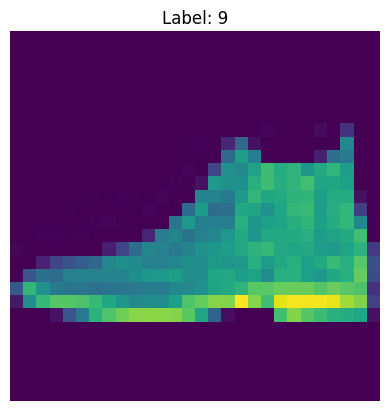

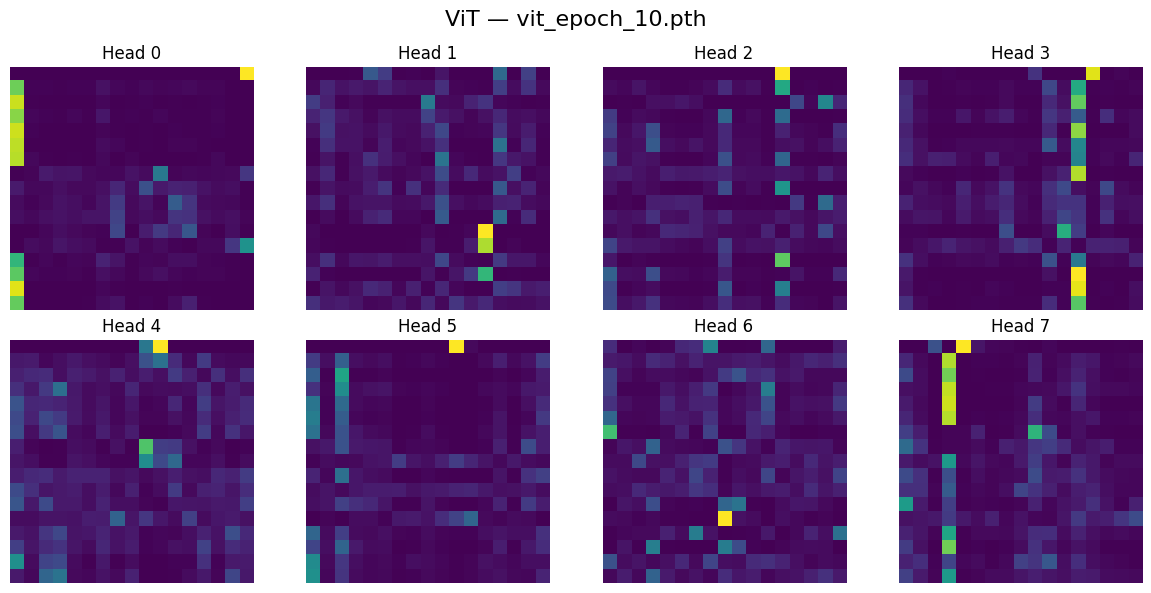

In [ ]:


import matplotlib.pyplot as plt



plt.imshow(image.permute(1, 2, 0))  # если формат (C, H, W)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("ViT — vit_epoch_10.pth", fontsize=16)

for h in range(8):
    A = attn[0, h].cpu()
    ax = axes[h // 4, h % 4]
    im = ax.imshow(A)
    ax.set_title(f"Head {h}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch

num_heads = attn.shape[1]

for h in range(num_heads):
    A = attn[0, h]  # (tokens, tokens)

    # энтропия по строкам
    entropy_per_token = -(A * torch.log(A + 1e-9)).sum(dim=-1)
    print(f"Head {h}:")
    print(entropy_per_token)

    # средняя энтропия головы
    entropy = entropy_per_token.mean().item()

    print(f" Entropy = {entropy:.4f}")

Head 0:
tensor([0.0338, 1.1067, 0.4978, 0.8855, 0.4784, 0.5510, 0.5973, 2.1239, 2.5146,
        2.2950, 2.5449, 2.0701, 1.8050, 1.4446, 1.2059, 0.2951, 0.9977])
 Entropy = 1.2616
Head 1:
tensor([1.5905, 2.5178, 1.9478, 2.5738, 2.4480, 2.0977, 2.0901, 2.4431, 2.2448,
        2.5513, 1.8249, 0.3440, 0.7876, 2.5021, 1.2869, 2.4474, 2.6387])
 Entropy = 2.0198
Head 2:
tensor([0.0147, 1.5667, 1.6493, 1.6258, 2.2411, 2.4390, 1.9043, 2.7555, 1.5823,
        1.9884, 2.7212, 2.4841, 2.5153, 0.8725, 2.1065, 1.3894, 2.3927])
 Entropy = 1.8970
Head 3:
tensor([0.5414, 1.5898, 1.1885, 2.3385, 1.0631, 1.9024, 2.1071, 0.9204, 2.3763,
        2.6097, 2.4965, 1.2848, 2.5904, 2.0305, 0.4966, 0.7291, 1.2836])
 Entropy = 1.6205
Head 4:
tensor([0.6117, 2.3441, 2.7011, 2.4601, 2.5569, 2.5287, 2.3638, 1.7176, 1.9485,
        2.7328, 2.6173, 2.5245, 2.5522, 2.5568, 2.6133, 2.0166, 2.1328])
 Entropy = 2.2929
Head 5:
tensor([0.1330, 2.1752, 1.1924, 1.9174, 1.6502, 1.5882, 1.9635, 2.2425, 2.5521,
        1.9506, 2

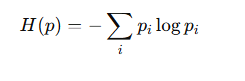

ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

C:\Users\user\AppData\Local\Temp\ipykernel_7256\3644072237.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vit_epoch_20.pth"))


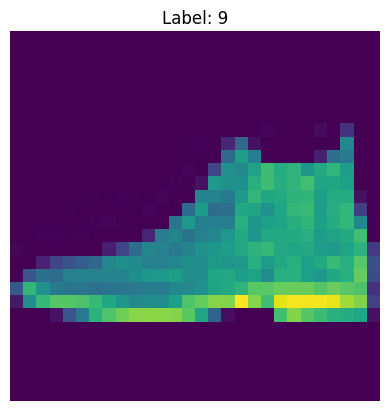

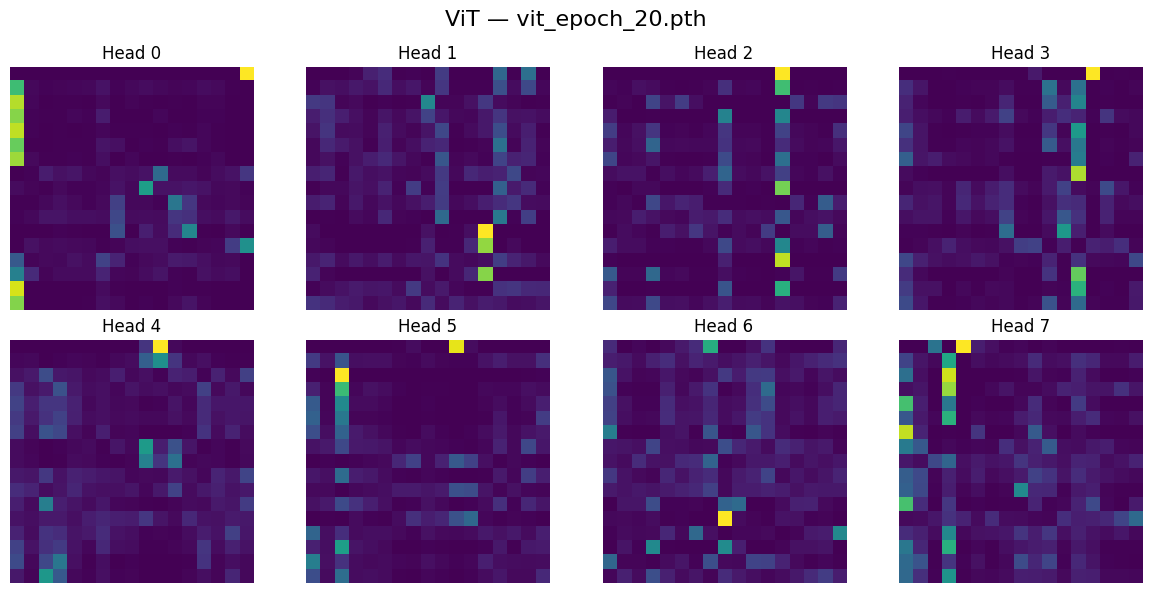

Head 0:
tensor([0.0563, 1.4428, 0.6484, 0.8769, 0.5851, 1.0633, 0.7787, 2.2644, 1.8298,
        1.9835, 2.5138, 1.5627, 1.8294, 2.3119, 2.0716, 0.3803, 0.8929])
 Entropy = 1.3583
Head 1:
tensor([1.6176, 2.3245, 1.8333, 2.5871, 2.3933, 2.2283, 2.3493, 2.4823, 2.1467,
        2.5980, 1.5970, 0.5168, 1.0062, 2.6483, 1.0302, 2.5230, 2.6979])
 Entropy = 2.0341
Head 2:
tensor([0.0113, 1.2333, 2.0061, 1.0322, 2.2090, 2.2778, 1.7994, 2.2651, 0.8580,
        2.0633, 2.4811, 2.1946, 1.8183, 0.3706, 1.8455, 0.9726, 2.4220])
 Entropy = 1.6388
Head 3:
tensor([0.3253, 1.7181, 1.6009, 2.5041, 1.5503, 1.8564, 1.7889, 0.8108, 2.4247,
        2.5453, 2.3053, 1.3423, 2.4383, 2.3770, 0.9711, 1.4825, 1.9142])
 Entropy = 1.7621
Head 4:
tensor([0.4827, 1.7488, 2.5244, 2.4925, 2.5207, 2.5810, 2.2332, 1.8176, 1.7642,
        2.6162, 2.6728, 2.1921, 2.7370, 2.5740, 2.4714, 1.9037, 1.7404])
 Entropy = 2.1808
Head 5:
tensor([0.3407, 2.3856, 0.2148, 1.4481, 1.6431, 1.5976, 2.1647, 2.4177, 2.0852,
        2.1532, 2

In [ ]:

from vit import ViT
import torch
import torchvision
import torchvision.transforms as transforms

# создаем модель
model = ViT()

# загружаем чекпоинт
model.load_state_dict(torch.load("vit_epoch_20.pth"))
model.eval()

print(model)



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# берем изображение из FashionMNIST
image, label = test_dataset[0]
sample_image = image.unsqueeze(0)

# forward
with torch.no_grad():
    _ = model(sample_image)

# достаем attention
# (batch,heads,tokens,tokens)
attn = model.transformer[0].attn.last_attn
print(attn.shape)


# %%


import matplotlib.pyplot as plt


plt.imshow(image.permute(1, 2, 0))  # если формат (C, H, W)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("ViT — vit_epoch_20.pth", fontsize=16)


for h in range(8):
    A = attn[0, h].cpu()
    ax = axes[h // 4, h % 4]
    im = ax.imshow(A)
    ax.set_title(f"Head {h}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# %%
import torch

num_heads = attn.shape[1]

for h in range(num_heads):
    A = attn[0, h]  # (tokens, tokens)

    # энтропия по строкам
    entropy_per_token = -(A * torch.log(A + 1e-9)).sum(dim=-1)
    print(f"Head {h}:")
    print(entropy_per_token)

    # средняя энтропия головы
    entropy = entropy_per_token.mean().item()

    print(f" Entropy = {entropy:.4f}")






ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

C:\Users\user\AppData\Local\Temp\ipykernel_7256\443785888.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vit_epoch_30.pth"))


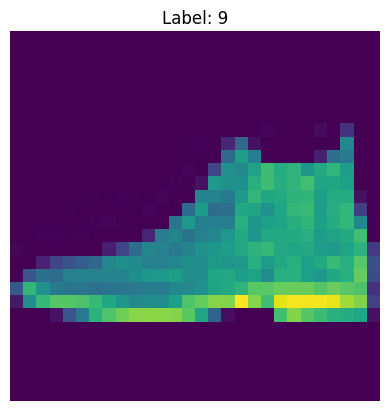

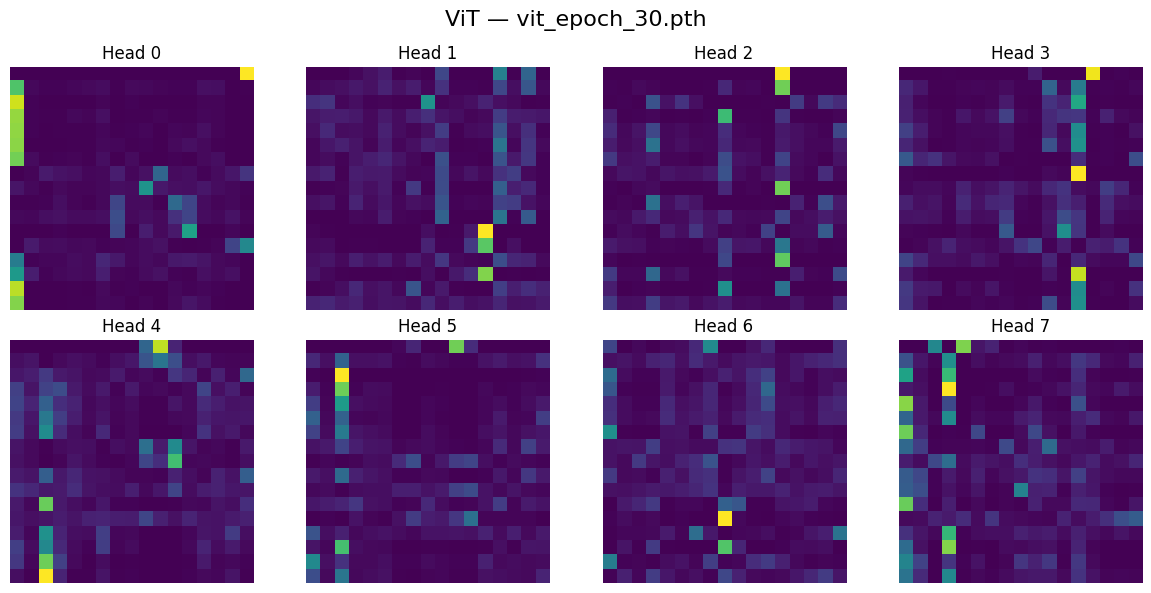

Head 0:
tensor([0.0583, 1.3126, 0.4551, 0.8428, 0.8681, 0.8842, 1.0286, 2.3001, 1.9763,
        1.9611, 2.3954, 1.3384, 1.8418, 2.1439, 1.8214, 0.5917, 0.9114])
 Entropy = 1.3371
Head 1:
tensor([1.5257, 2.3579, 1.9076, 2.6753, 2.4204, 2.2326, 2.2422, 2.4581, 2.1138,
        2.3650, 1.5663, 0.5449, 1.2471, 2.5234, 1.1098, 2.3298, 2.7534])
 Entropy = 2.0220
Head 2:
tensor([0.0146, 0.9188, 1.9965, 1.1338, 2.3166, 2.2505, 2.2631, 2.4976, 0.8810,
        1.8505, 2.5696, 2.2032, 2.0540, 0.7156, 1.9677, 1.1680, 2.5242])
 Entropy = 1.7250
Head 3:
tensor([0.3613, 1.7870, 1.5015, 2.4359, 1.8519, 1.7011, 2.0545, 0.3591, 2.5505,
        2.5822, 2.3699, 1.5033, 2.4294, 2.3808, 0.6299, 1.7561, 1.6494])
 Entropy = 1.7590
Head 4:
tensor([0.8222, 2.1740, 2.4319, 2.4251, 2.4340, 2.3233, 2.0951, 2.0050, 1.7198,
        2.3844, 2.6812, 1.6677, 2.7415, 2.0811, 2.0972, 1.4412, 1.0885])
 Entropy = 2.0361
Head 5:
tensor([0.8104, 2.3366, 0.2053, 1.1063, 1.6825, 1.8440, 2.0523, 2.4426, 2.2239,
        2.2261, 2

In [ ]:

from vit import ViT
import torch
import torchvision
import torchvision.transforms as transforms

# создаем модель
model = ViT()

# загружаем чекпоинт
model.load_state_dict(torch.load("vit_epoch_30.pth"))
model.eval()

print(model)



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# берем изображение из FashionMNIST
image, label = test_dataset[0]
sample_image = image.unsqueeze(0)

# forward
with torch.no_grad():
    _ = model(sample_image)

# достаем attention
# (batch,heads,tokens,tokens)
attn = model.transformer[0].attn.last_attn
print(attn.shape)


# %%


import matplotlib.pyplot as plt


plt.imshow(image.permute(1, 2, 0))  # если формат (C, H, W)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("ViT — vit_epoch_30.pth", fontsize=16)


for h in range(8):
    A = attn[0, h].cpu()
    ax = axes[h // 4, h % 4]
    im = ax.imshow(A)
    ax.set_title(f"Head {h}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# %%
import torch

num_heads = attn.shape[1]

for h in range(num_heads):
    A = attn[0, h]  # (tokens, tokens)

    # энтропия по строкам
    entropy_per_token = -(A * torch.log(A + 1e-9)).sum(dim=-1)
    print(f"Head {h}:")
    print(entropy_per_token)

    # средняя энтропия головы
    entropy = entropy_per_token.mean().item()

    print(f" Entropy = {entropy:.4f}")






ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

C:\Users\user\AppData\Local\Temp\ipykernel_7256\2147895923.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vit_epoch_40.pth"))


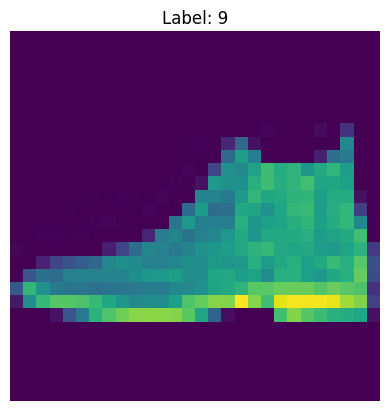

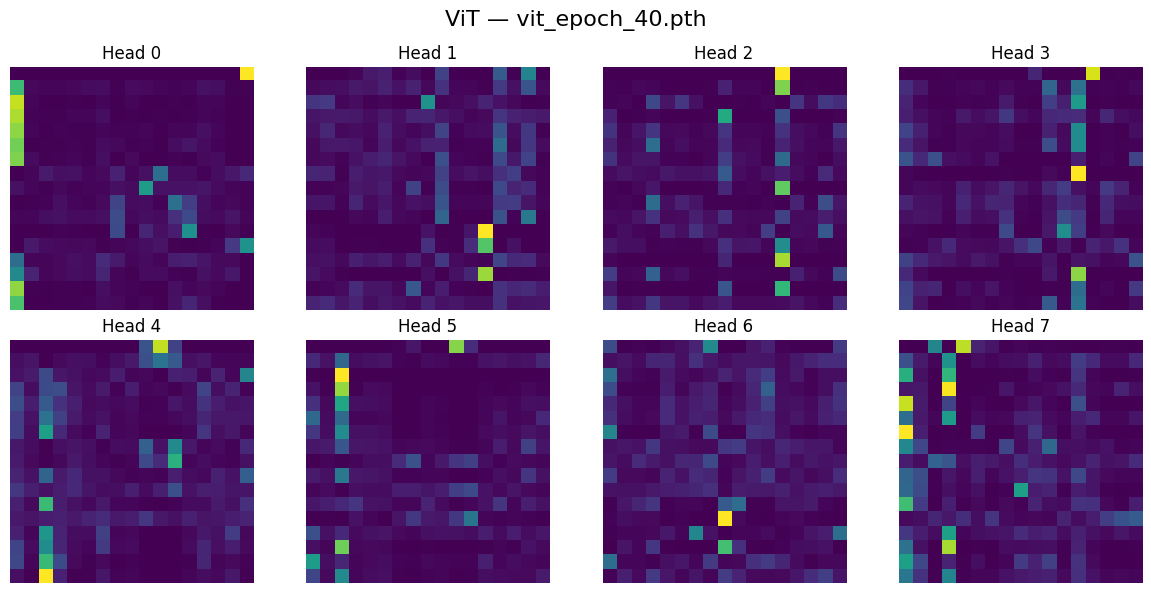

Head 0:
tensor([0.0991, 1.4665, 0.5486, 0.7226, 0.9190, 1.0520, 0.9864, 2.2704, 1.8768,
        1.9664, 2.3934, 1.5422, 1.8103, 2.2634, 1.9871, 0.8674, 1.2184])
 Entropy = 1.4112
Head 1:
tensor([1.6215, 2.4470, 1.8732, 2.7236, 2.3683, 2.3098, 2.2691, 2.4958, 2.1969,
        2.4101, 1.5958, 0.5781, 1.3112, 2.5337, 1.0468, 2.3580, 2.7284])
 Entropy = 2.0510
Head 2:
tensor([0.0192, 0.8542, 2.1196, 1.1530, 2.3584, 2.2429, 2.0986, 2.4830, 0.9772,
        1.9292, 2.5328, 2.2706, 1.8723, 0.5008, 2.0010, 0.9194, 2.5473])
 Entropy = 1.6988
Head 3:
tensor([0.4287, 1.8194, 1.5635, 2.5690, 1.8132, 1.7264, 2.0065, 0.3130, 2.5182,
        2.5885, 2.3747, 1.5407, 2.4069, 2.3850, 0.8275, 1.9159, 1.7208])
 Entropy = 1.7952
Head 4:
tensor([0.8972, 2.1910, 2.2543, 2.3736, 2.4507, 2.3648, 1.9744, 2.1324, 1.8887,
        2.3620, 2.6687, 1.9074, 2.7820, 2.0504, 2.1106, 1.5935, 1.1629])
 Entropy = 2.0685
Head 5:
tensor([0.6846, 2.3324, 0.1244, 0.8351, 1.6236, 1.7889, 1.9045, 2.3554, 2.2651,
        2.1084, 2

In [ ]:

from vit import ViT
import torch
import torchvision
import torchvision.transforms as transforms

# создаем модель
model = ViT()

# загружаем чекпоинт
model.load_state_dict(torch.load("vit_epoch_40.pth"))
model.eval()

print(model)



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# берем изображение из FashionMNIST
image, label = test_dataset[0]
sample_image = image.unsqueeze(0)

# forward
with torch.no_grad():
    _ = model(sample_image)

# достаем attention
# (batch,heads,tokens,tokens)
attn = model.transformer[0].attn.last_attn
print(attn.shape)


# %%


import matplotlib.pyplot as plt

plt.imshow(image.permute(1, 2, 0))  # если формат (C, H, W)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("ViT — vit_epoch_40.pth", fontsize=16)


for h in range(8):
    A = attn[0, h].cpu()
    ax = axes[h // 4, h % 4]
    im = ax.imshow(A)
    ax.set_title(f"Head {h}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# %%
import torch

num_heads = attn.shape[1]

for h in range(num_heads):
    A = attn[0, h]  # (tokens, tokens)

    # энтропия по строкам
    entropy_per_token = -(A * torch.log(A + 1e-9)).sum(dim=-1)
    print(f"Head {h}:")
    print(entropy_per_token)

    # средняя энтропия головы
    entropy = entropy_per_token.mean().item()

    print(f" Entropy = {entropy:.4f}")






ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

C:\Users\user\AppData\Local\Temp\ipykernel_7256\3482962859.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vit_epoch_50.pth"))


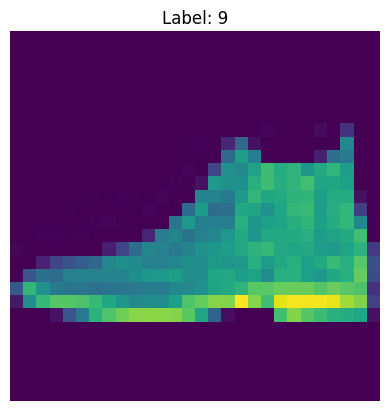

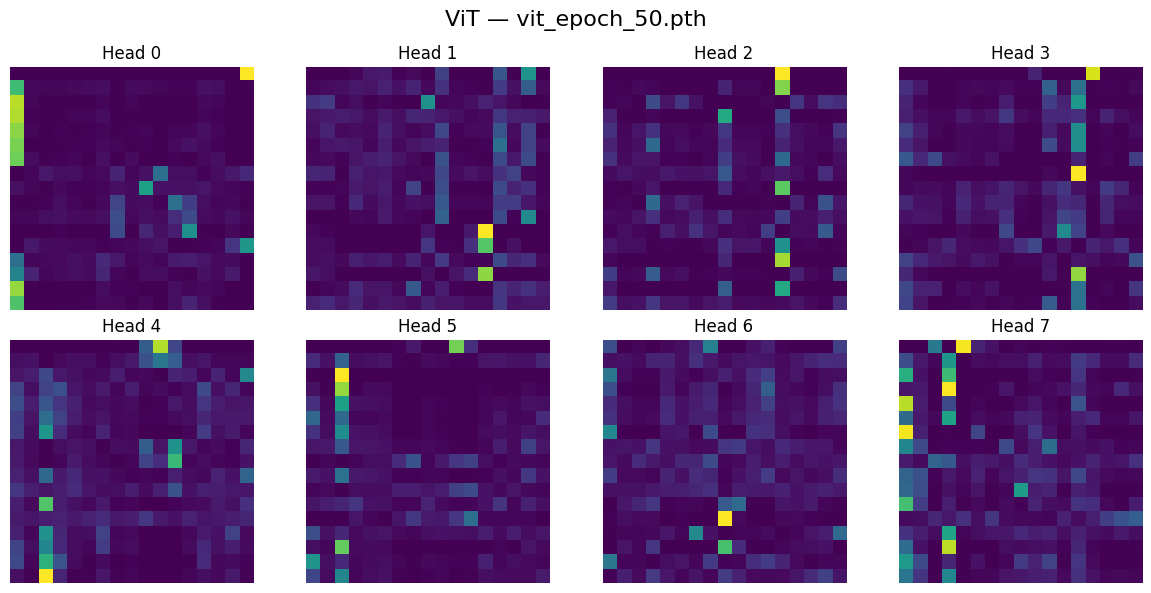

Head 0:
tensor([0.0837, 1.4453, 0.6074, 0.6981, 0.9310, 1.0043, 1.0723, 2.2698, 1.8271,
        1.9573, 2.3531, 1.5140, 1.7763, 2.2659, 2.0362, 0.8373, 1.2138])
 Entropy = 1.4055
Head 1:
tensor([1.5583, 2.3986, 1.9130, 2.7141, 2.3383, 2.2758, 2.2398, 2.4800, 2.1950,
        2.3919, 1.5417, 0.6429, 1.3337, 2.4996, 1.1489, 2.3344, 2.7247])
 Entropy = 2.0430
Head 2:
tensor([0.0204, 0.8472, 2.1092, 1.1740, 2.3678, 2.2755, 2.0997, 2.5003, 1.0154,
        1.9385, 2.5500, 2.2520, 1.8129, 0.5124, 2.0404, 1.0035, 2.5562])
 Entropy = 1.7103
Head 3:
tensor([0.4220, 1.8686, 1.6120, 2.5624, 1.7987, 1.7305, 2.0293, 0.2967, 2.5396,
        2.5925, 2.4107, 1.5626, 2.4345, 2.3936, 0.7881, 1.8760, 1.7523])
 Entropy = 1.8041
Head 4:
tensor([0.9385, 2.1708, 2.2553, 2.4212, 2.4731, 2.4069, 2.0395, 2.1041, 1.8597,
        2.3288, 2.6733, 1.8387, 2.7855, 2.1010, 2.1722, 1.6557, 1.2058])
 Entropy = 2.0841
Head 5:
tensor([0.7579, 2.3669, 0.1191, 0.8352, 1.6949, 1.8285, 1.9071, 2.3419, 2.2546,
        2.1628, 2

In [ ]:

from vit import ViT
import torch
import torchvision
import torchvision.transforms as transforms

# создаем модель
model = ViT()

# загружаем чекпоинт
model.load_state_dict(torch.load("vit_epoch_50.pth"))
model.eval()

print(model)



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# берем изображение из FashionMNIST
image, label = test_dataset[0]
sample_image = image.unsqueeze(0)

# forward
with torch.no_grad():
    _ = model(sample_image)

# достаем attention
# (batch,heads,tokens,tokens)
attn = model.transformer[0].attn.last_attn
print(attn.shape)


# %%


import matplotlib.pyplot as plt


plt.imshow(image.permute(1, 2, 0))  # если формат (C, H, W)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("ViT — vit_epoch_50.pth", fontsize=16)


for h in range(8):
    A = attn[0, h].cpu()
    ax = axes[h // 4, h % 4]
    im = ax.imshow(A)
    ax.set_title(f"Head {h}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# %%
import torch

num_heads = attn.shape[1]

for h in range(num_heads):
    A = attn[0, h]  # (tokens, tokens)

    # энтропия по строкам
    entropy_per_token = -(A * torch.log(A + 1e-9)).sum(dim=-1)
    print(f"Head {h}:")
    print(entropy_per_token)

    # средняя энтропия головы
    entropy = entropy_per_token.mean().item()

    print(f" Entropy = {entropy:.4f}")




